In [2]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [3]:
device = torch.device('cpu')
device

device(type='cpu')

In [4]:
rng = np.random.default_rng(73512)

# Dane syntetyczne

In [5]:
indices = np.arange(0, 50, 0.02)
synthetic_data = (np.sin(indices * 3) + indices / 10 + (indices / 10) ** 2 + np.sin(indices * 10)) #/ np.exp(indices / 20)

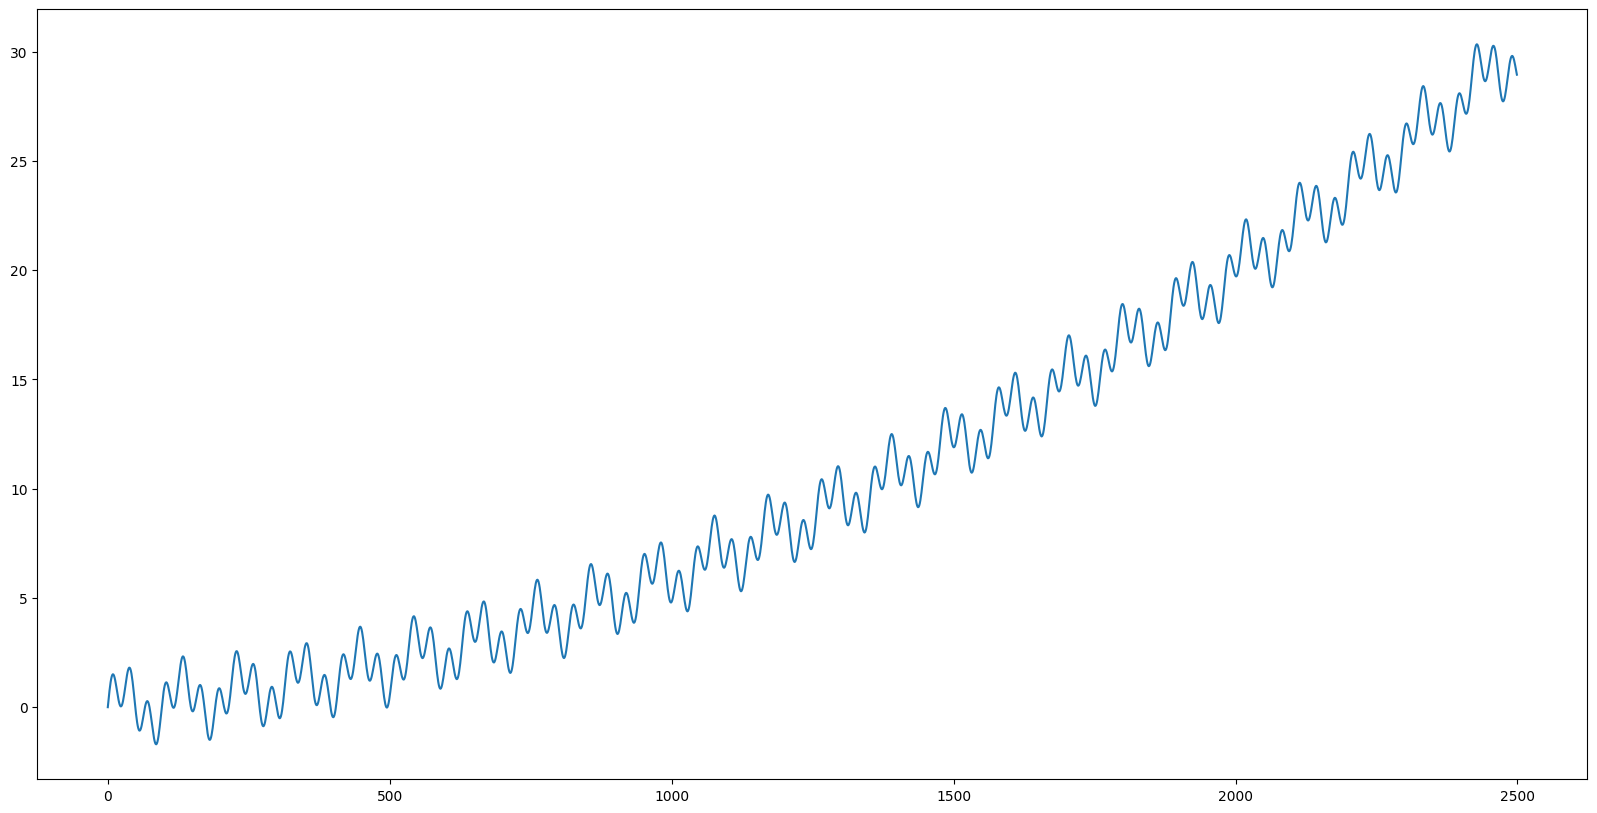

In [6]:
plt.figure(figsize=[20, 10])
plt.plot(synthetic_data)
plt.show()

In [7]:
min_value = synthetic_data.min()
max_value = synthetic_data.max()

In [8]:
data_seq = []
data_targets = []
sequence_len = 150
for i in range(len(synthetic_data) - sequence_len - 1):
    data_seq.append(torch.from_numpy(synthetic_data[i:i + sequence_len]))
    data_targets.append(synthetic_data[i + sequence_len + 1])

In [ ]:
data = (torch.stack(data_seq).float() - min_value) / max_value
data_targets = (torch.Tensor(data_targets).float() - min_value) / max_value
train_indices = rng.random(len(data_seq)) > 0.3
test_indices = ~train_indices
train_set = torch.utils.data.TensorDataset(data[train_indices], data_targets[train_indices])
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_data, test_targets = data[test_indices], data_targets[test_indices]

In [10]:
class SimpleRegressor(nn.Module):

    def __init__(self, num_inputs, num_hidden, num_outputs):
        super().__init__()
        self.linear1 = nn.Linear(num_inputs, num_hidden)
        self.act_fn = nn.Tanh()
        self.linear2 = nn.Linear(num_hidden, num_outputs)

    def forward(self, x):
        x = self.linear1(x)
        x = self.act_fn(x)
        x = self.linear2(x)
        return x
    
model = SimpleRegressor(sequence_len, 5, 1).to(device)
model

SimpleRegressor(
  (linear1): Linear(in_features=150, out_features=5, bias=True)
  (act_fn): Tanh()
  (linear2): Linear(in_features=5, out_features=1, bias=True)
)

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fun = nn.MSELoss()

In [12]:
model.train() 

# Training loop
for epoch in range(101):
    for x, targets in train_loader:
        x = x.to(device)
        targets = targets.to(device)

        preds = model(x)
        preds = preds.squeeze(dim=1) 
        
        optimizer.zero_grad() 
        loss = loss_fun(preds, targets)
        loss.backward()
        optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}, loss: {loss.item():.3}")

Epoch: 0, loss: 0.00752
Epoch: 10, loss: 0.000757
Epoch: 20, loss: 0.000862
Epoch: 30, loss: 0.000732
Epoch: 40, loss: 0.000224
Epoch: 50, loss: 0.00015
Epoch: 60, loss: 5.3e-05
Epoch: 70, loss: 3.96e-05
Epoch: 80, loss: 0.000265
Epoch: 90, loss: 0.000114
Epoch: 100, loss: 4.13e-05


In [13]:
with torch.no_grad():
    test_preds = model(test_data.to(device))
    print(torch.abs(test_preds.squeeze()-test_targets.to(device)).mean())

tensor(0.0055)


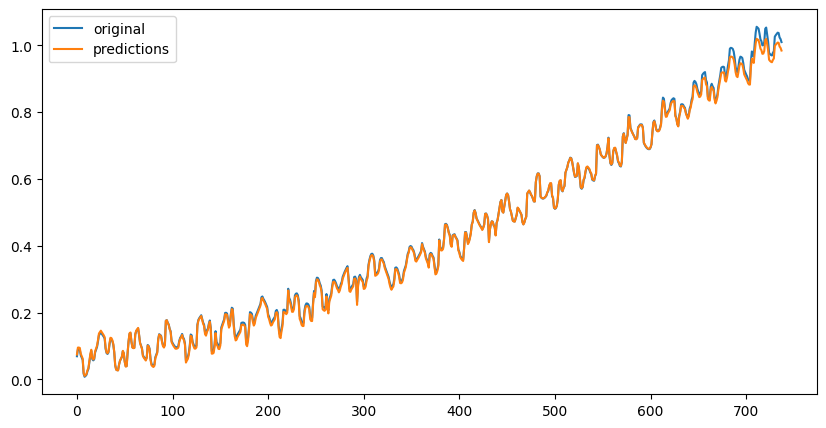

In [14]:
plt.figure(figsize=[10, 5])
plt.plot(test_targets.numpy(), label='original')
plt.plot(test_preds.cpu().numpy(), label='predictions')
plt.legend()
plt.show()

## Koniec laborki?

### Co poszło nie tak?

In [15]:
train_split = int(len(data) * 0.7)
train_set = torch.utils.data.TensorDataset(data[:train_split], data_targets[:train_split])
train_loader = DataLoader(train_set, batch_size=32, drop_last=True)
test_data, test_targets = data[train_split:], data_targets[train_split:]

In [16]:
model = SimpleRegressor(sequence_len, 5, 1).to(device)
model
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fun = nn.MSELoss()

# Training loop
for epoch in range(101):
    for x, targets in train_loader:
        x = x.to(device)
        targets = targets.to(device)

        preds = model(x)
        preds = preds.squeeze(dim=1) 
        
        optimizer.zero_grad() 
        loss = loss_fun(preds, targets)
        loss.backward()
        optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}, loss: {loss.item():.3}")

Epoch: 0, loss: 0.000654
Epoch: 10, loss: 0.000108
Epoch: 20, loss: 0.000121
Epoch: 30, loss: 0.000128
Epoch: 40, loss: 9.75e-05
Epoch: 50, loss: 6.46e-05
Epoch: 60, loss: 2.6e-05
Epoch: 70, loss: 5.15e-05
Epoch: 80, loss: 7.49e-05
Epoch: 90, loss: 0.000105
Epoch: 100, loss: 0.000122


In [17]:
with torch.no_grad():
    test_preds = model(test_data.to(device))
    print(torch.abs(test_preds.squeeze() - test_targets.to(device)).mean())

tensor(0.1349)


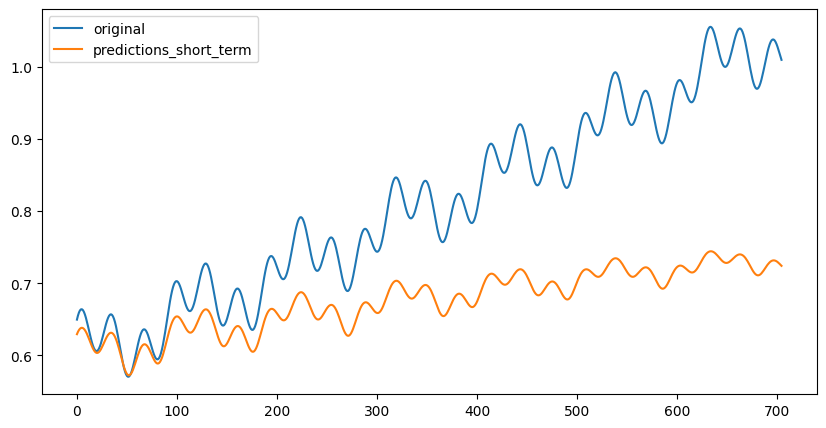

In [18]:
plt.figure(figsize=[10, 5])
plt.plot(test_targets.numpy(), label='original')
plt.plot(test_preds.cpu().numpy(), label='predictions_short_term')
plt.legend()
plt.show()

# Sieć rekurencyjna

In [34]:
class RecurrentRegressor(nn.Module):

    def __init__(self, num_inputs, num_hidden, num_outputs, num_state):
        super().__init__()
        self.linear1 = nn.Linear(num_inputs + num_state, num_hidden)
        self.act_fn = nn.Tanh()
        self.linear_out = nn.Linear(num_hidden, num_outputs)
        self.linear_state = nn.Linear(num_hidden, num_state)

    def forward(self, x, state):
        x = torch.cat([x, state], 1)
        x = self.linear1(x)
        x = self.act_fn(x)
        out = self.linear_out(x)
        state = self.linear_state(x)
        return out, state
    
model = RecurrentRegressor(1, 5, 1, 5).to(device)
model

RecurrentRegressor(
  (linear1): Linear(in_features=6, out_features=5, bias=True)
  (act_fn): Tanh()
  (linear_out): Linear(in_features=5, out_features=1, bias=True)
  (linear_state): Linear(in_features=5, out_features=5, bias=True)
)

### Dokończ pętlę uczącą poniżej:

In [35]:
next(iter(train_loader))[0].shape

torch.Size([32, 150])

In [39]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fun = nn.MSELoss()

for epoch in range(101):
    for x, targets in train_loader:
        x = x.to(device)
        targets = targets.to(device)
        loss_total = 0
        state = torch.zeros(len(x), 5).to(device)
        optimizer.zero_grad() 
        for i in range(x.size(1)):
            x_one = x[:,i].unsqueeze(1)
            if i < sequence_len - 1:
                target = x[:,i+1]
            else:
                target = targets
            preds, state = model(x_one, state)
            preds = preds.squeeze(dim=1) 
            loss = loss_fun(preds, target)
            loss_total += loss
        loss_total.backward()
        optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}, loss: {loss.item():.3}")

Epoch: 0, loss: 7.84e-05
Epoch: 10, loss: 6.61e-05
Epoch: 20, loss: 6.31e-05
Epoch: 30, loss: 6.21e-05
Epoch: 40, loss: 6.33e-05
Epoch: 50, loss: 6.18e-05
Epoch: 60, loss: 5.81e-05
Epoch: 70, loss: 5.72e-05
Epoch: 80, loss: 5.66e-05
Epoch: 90, loss: 5.61e-05
Epoch: 100, loss: 5.65e-05


In [40]:
with torch.no_grad():
    state = torch.zeros(len(test_data), 5).to(device)
    test_preds = []
    for i in range(test_data.size(1)):
        x_one = test_data[:, i].unsqueeze(1).to(device)
        preds, state = model(x_one, state)
    test_preds.append(preds)
    print(torch.abs((torch.cat(test_preds).squeeze() - test_targets.to(device))).mean())

tensor(0.0175)


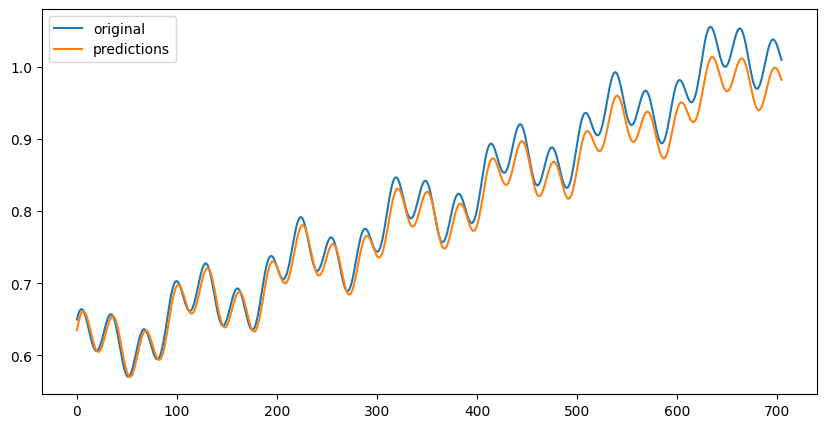

In [41]:
plt.figure(figsize=[10, 5])
plt.plot(test_targets, label='original')
plt.plot(torch.cat(test_preds).squeeze().cpu().numpy(), label='predictions')
plt.legend()
plt.show()

# Sieci rekurencyjne w Torchu

In [47]:
batch_size = 2
input_size = 3
hidden_size = 4
num_layers = 2
rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, num_layers=2, batch_first=False) #batch_first=False is default!!
rnn

RNN(3, 4, num_layers=2)

In [53]:
with torch.no_grad():
    sequence_len = 5
    x = torch.randn(sequence_len, batch_size, input_size)
    h0 = torch.randn(num_layers, batch_size, hidden_size)
    # print(rnn(x, h0))
    output, hn = rnn(x, h0)
output

tensor([[[-0.7571,  0.6829, -0.7499, -0.6769],
         [-0.6541,  0.1026,  0.3926,  0.6046]],

        [[ 0.4275, -0.3521,  0.4233,  0.8852],
         [ 0.2408,  0.1777,  0.4017,  0.4321]],

        [[-0.2483,  0.6239,  0.2164, -0.3149],
         [-0.4628,  0.5017,  0.2158, -0.0085]],

        [[-0.1188,  0.2557,  0.6193,  0.7367],
         [-0.1995,  0.0275,  0.1671,  0.6926]],

        [[-0.3657,  0.0489, -0.0795, -0.0057],
         [-0.1230,  0.2758, -0.0893,  0.4007]]])

In [54]:
output[-1]

tensor([[-0.3657,  0.0489, -0.0795, -0.0057],
        [-0.1230,  0.2758, -0.0893,  0.4007]])

In [55]:
hn

tensor([[[-0.0278,  0.4150, -0.9786,  0.6288],
         [ 0.2773, -0.4125,  0.8231, -0.7167]],

        [[-0.3657,  0.0489, -0.0795, -0.0057],
         [-0.1230,  0.2758, -0.0893,  0.4007]]])

In [56]:
class RNNRegressor(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, out_size):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers)
        self.fc = nn.Linear(hidden_size, out_size)
        
    def init_hidden(self, batch_size):
        hidden = torch.zeros(self.num_layers, batch_size, self.hidden_size)
        return hidden
    
    def forward(self, x, hidden):
        x = torch.transpose(x, 0, 1)
        all_outputs, hidden = self.rnn(x, hidden)
        out = all_outputs[-1] # We are interested only in the last output
        x = self.fc(out)
        return x, hidden
    
model = RNNRegressor(1, 5, 2, 1).to(device)
model

RNNRegressor(
  (rnn): RNN(1, 5, num_layers=2)
  (fc): Linear(in_features=5, out_features=1, bias=True)
)

In [59]:
next(iter(train_loader))[0].unsqueeze(2).shape

torch.Size([32, 150, 1])

In [63]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fun = nn.MSELoss()

for epoch in range(101):
    for x, targets in train_loader:
        x = x.to(device).unsqueeze(2)
        targets = targets.to(device)
        hidden = model.init_hidden(x.size(0)).to(device)
        preds, last_hidden = model(x, hidden)
        preds = preds.squeeze(1)
        optimizer.zero_grad() 
        loss = loss_fun(preds, targets)
        loss.backward()
        optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}, loss: {loss.item():.3}")

Epoch: 0, loss: 4.5e-05
Epoch: 10, loss: 3.56e-05
Epoch: 20, loss: 3.05e-05
Epoch: 30, loss: 2.63e-05
Epoch: 40, loss: 2.25e-05
Epoch: 50, loss: 1.9e-05
Epoch: 60, loss: 1.57e-05
Epoch: 70, loss: 1.22e-05
Epoch: 80, loss: 9.43e-06
Epoch: 90, loss: 7.98e-06
Epoch: 100, loss: 8.75e-06


In [64]:
with torch.no_grad():
    hidden = model.init_hidden(len(test_data)).to(device)
    test_preds, _ = model(test_data.to(device).unsqueeze(2),hidden)
    print(torch.abs(test_preds.squeeze() - test_targets.to(device)).mean())

tensor(0.0412)


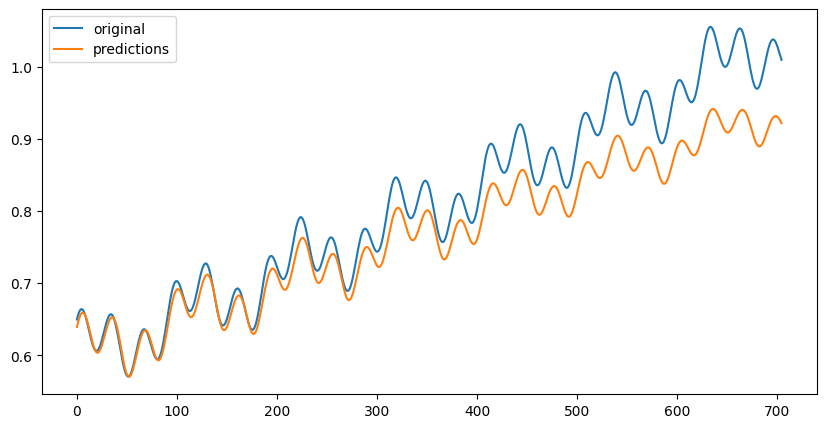

In [65]:
plt.figure(figsize=[10, 5])
plt.plot(test_targets, label='original')
plt.plot(test_preds.squeeze().cpu().numpy(), label='predictions')
plt.legend()
plt.show()

## Czy możemy jakoś rozdzielić krótką i długą pamięć?

![LSTM](https://cdn-images-1.medium.com/max/1000/1*Ht2-sUJHi65wDwnR276k3A.png)

In [66]:
sequence_length = 5
num_layers = 1
batch_size = 3
hidden_size = 2
lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, num_layers=num_layers)
lstm_input = torch.randn(sequence_length, batch_size, 1)
hidden_0 = torch.randn(num_layers, batch_size, hidden_size)
cell_state_0 = torch.randn(num_layers, batch_size, hidden_size)
output, (hn, cn) = lstm(lstm_input, (hidden_0, cell_state_0))

In [67]:
print(output.size())
output

torch.Size([5, 3, 2])


tensor([[[ 0.2022, -0.2124],
         [ 0.0707,  0.1272],
         [-0.0504,  0.0479]],

        [[ 0.1569, -0.2525],
         [-0.2105,  0.1632],
         [ 0.0679, -0.1077]],

        [[ 0.1554, -0.1138],
         [-0.0061, -0.0110],
         [ 0.1239, -0.2061]],

        [[ 0.1451, -0.0897],
         [ 0.0822, -0.1068],
         [ 0.1491, -0.1503]],

        [[ 0.1540, -0.1197],
         [ 0.1306, -0.1591],
         [ 0.1397, -0.0930]]], grad_fn=<MkldnnRnnLayerBackward0>)

In [68]:
print(hn)
print(cn)

tensor([[[ 0.1540, -0.1197],
         [ 0.1306, -0.1591],
         [ 0.1397, -0.0930]]], grad_fn=<StackBackward0>)
tensor([[[ 0.4246, -0.1879],
         [ 0.3785, -0.2542],
         [ 0.3508, -0.1416]]], grad_fn=<StackBackward0>)


In [69]:
class LSTMRegressor(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, out_size):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers)
        self.fc = nn.Linear(hidden_size, out_size)
        
    def init_hidden(self, batch_size):
        hidden = torch.zeros(self.num_layers, batch_size, self.hidden_size)
        state = torch.zeros(self.num_layers, batch_size, self.hidden_size)
        return hidden, state
    
    def forward(self, x, hidden):
        x = torch.transpose(x, 0, 1)
        all_outputs, hidden = self.lstm(x, hidden)
        out = all_outputs[-1] # We are interested only in the last output
        x = self.fc(out)
        return x, hidden
    
model = LSTMRegressor(1, 20, 2, 1).to(device)
model

LSTMRegressor(
  (lstm): LSTM(1, 20, num_layers=2)
  (fc): Linear(in_features=20, out_features=1, bias=True)
)

In [70]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fun = nn.MSELoss()

for epoch in range(101):
    for x, targets in train_loader:
        x = x.to(device).unsqueeze(2)
        targets = targets.to(device)
        hidden, state = model.init_hidden(x.size(0))
        hidden, state = hidden.to(device), state.to(device) 
        preds, last_hidden = model(x, (hidden,state))
        preds = preds.squeeze(1)
        optimizer.zero_grad() 
        loss = loss_fun(preds, targets)
        loss.backward()
        optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}, loss: {loss.item():.3}")

Epoch: 0, loss: 0.000967
Epoch: 10, loss: 0.000548
Epoch: 20, loss: 0.000451
Epoch: 30, loss: 0.000338
Epoch: 40, loss: 0.00019
Epoch: 50, loss: 4.17e-05
Epoch: 60, loss: 1.31e-05
Epoch: 70, loss: 7.51e-06
Epoch: 80, loss: 4.29e-06
Epoch: 90, loss: 4.2e-06
Epoch: 100, loss: 4.48e-06


In [71]:
with torch.no_grad():
    hidden, state = model.init_hidden(test_data.size(0))
    hidden, state = hidden.to(device), state.to(device) 
    test_preds, _ = model(test_data.to(device).unsqueeze(2), (hidden, state))
    print(torch.abs(test_preds.squeeze() - test_targets.to(device)).mean().item())

0.009298831224441528


In [75]:
test_data.shape

torch.Size([705, 150])

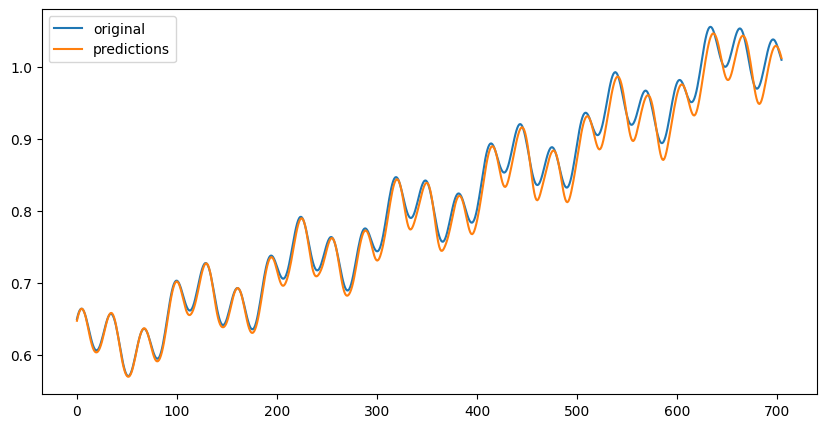

In [72]:
plt.figure(figsize=[10, 5])
plt.plot(test_targets, label='original')
plt.plot(test_preds.squeeze().cpu().numpy(), label='predictions')
plt.legend()
plt.show()

### Mini zadanie: Jak wyglądałyby predykcje w oparciu o poprzednie predykcje?

In [73]:
with torch.no_grad():
    hidden, state = model.init_hidden(1)
    hidden, state = hidden.to(device), state.to(device) 
    hidden = (hidden,state)
    x_one = test_targets[0:1].unsqueeze(0).to(device)
    preds = []
    for i in range(len(test_targets)):
        x_one, hidden = model(x_one.unsqueeze(0), hidden)
        preds.append(x_one.item())

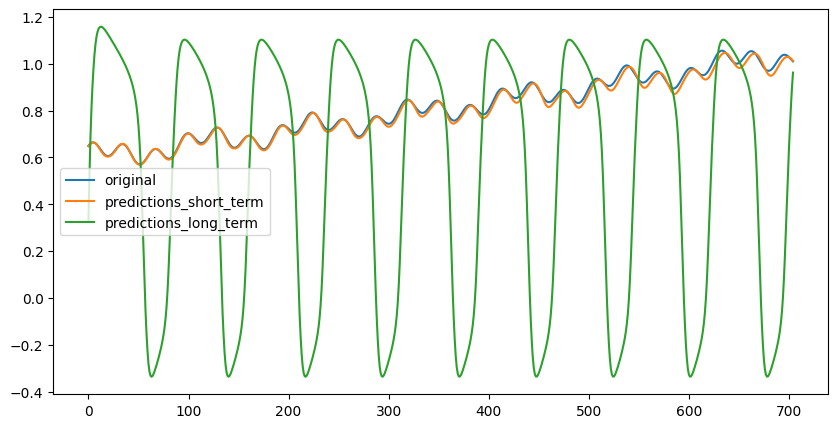

In [74]:
plt.figure(figsize=[10,5])
plt.plot(test_targets, label = 'original')
plt.plot(test_preds.squeeze().cpu().numpy(), label = 'predictions_short_term')
plt.plot(preds, label = 'predictions_long_term')
plt.legend()
plt.show()

# Predykcja Sequence to sequence

In [76]:
stock_price = pd.read_csv("https://www.galera.ii.pw.edu.pl/~kdeja/data/all_stocks_5yr.csv")

HTTPError: HTTP Error 404: Not Found

In [ ]:
mastercard_stock = stock_price[stock_price.Name=="MA"].open.values
visa_stock = stock_price[stock_price.Name=="V"].open.values

In [ ]:
plt.figure(figsize=[10, 5])
plt.plot(mastercard_stock, label='mastercard')
plt.plot(visa_stock, label='visa')
plt.legend()
plt.show()

In [ ]:
m_min_value = mastercard_stock.min()
m_max_value = mastercard_stock.max()
v_min_value = visa_stock.min()
v_max_value = visa_stock.max()

In [ ]:
data_seq = []
data_targets = []
sequence_len = 50
for i in range(len(mastercard_stock) - sequence_len):
    data_seq.append(torch.from_numpy(mastercard_stock[i:i + sequence_len]))
    data_targets.append(torch.from_numpy(visa_stock[i:i + sequence_len]))
    
data = (torch.stack(data_seq).float() - m_min_value) / m_max_value
data_targets = (torch.stack(data_targets).float() - v_min_value) / v_max_value    

train_split = int(len(data) * 0.7)
train_set = torch.utils.data.TensorDataset(data[:train_split], data_targets[:train_split])
train_loader = DataLoader(train_set, batch_size=32, drop_last=True)
train_set = torch.utils.data.TensorDataset(data[:train_split], data_targets[:train_split])
train_loader = DataLoader(train_set, batch_size=32, drop_last=True)
test_data, test_targets = data[train_split:], data_targets[train_split:]

In [ ]:
sequence_length = 5
num_layers = 1
batch_size = 3
hidden_size = 2
projection_size = 1

lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, num_layers=num_layers, proj_size=projection_size)
lstm_input = torch.randn(sequence_length, batch_size, 1)
hidden_0 = torch.randn(num_layers, batch_size, projection_size)
cell_state_0 = torch.randn(num_layers, batch_size, hidden_size)
output, (hn, cn) = lstm(lstm_input, (hidden_0, cell_state_0))

In [ ]:
output

In [ ]:
class LSTM_Seq_Regressor(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, out_size):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.proj_size = out_size
        self.lstm = nn.LSTM(input_size = input_size, hidden_size = hidden_size, num_layers = num_layers, proj_size=out_size)
        
    def init_hidden(self, batch_size):
        hidden = torch.zeros(self.num_layers, batch_size, self.proj_size)
        state = torch.zeros(self.num_layers, batch_size, self.hidden_size)
        return hidden, state
    
    def forward(self, x, hidden):
        x = torch.transpose(x,0,1)
        all_outputs, hidden = self.lstm(x, hidden)
        all_outputs = torch.transpose(all_outputs,0,1)
        return all_outputs, hidden
    
model = LSTM_Seq_Regressor(1, 50, 2, 1).to(device)
model

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fun = nn.MSELoss()

# Training loop
for epoch in range(101):
    for x, targets in train_loader:
        x = x.to(device).unsqueeze(2)
        targets = targets.to(device)
        hidden, state = model.init_hidden(x.size(0))
        hidden, state = hidden.to(device), state.to(device) 
        preds, last_hidden = model(x, (hidden,state))
        preds = preds.squeeze(2)
        optimizer.zero_grad() 
        loss = loss_fun(preds, targets)
        loss.backward()
        optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}, loss: {loss.item():.3}")

In [ ]:
with torch.no_grad():
    selected_test_targets = []
    preds = []
    for i in range(0, len(test_targets), sequence_len):
        hidden, state = model.init_hidden(1)
        hidden, state = hidden.to(device), state.to(device) 
        selected_test_targets.append(test_targets[i])
        pred, _ = model(test_data[i].to(device).unsqueeze(0).unsqueeze(2), (hidden, state))
        preds.append(pred.squeeze())

In [ ]:
plt.figure(figsize=[10, 5])
plt.plot(torch.cat(selected_test_targets).cpu().numpy(), label='original')
plt.plot(torch.cat(preds).cpu().numpy(), label='predicted')
plt.legend()
plt.show()

### Co się stało, skąd takie dziwne predykcje?

In [ ]:
with torch.no_grad():
    selected_test_targets = []
    preds = []
    hidden, state = model.init_hidden(1)
    hidden, state = hidden.to(device), state.to(device) 
    for i in range(0,len(test_targets),sequence_len):
        selected_test_targets.append(test_targets[i])
        pred, hidden_out = model(test_data[i].to(device).unsqueeze(0).unsqueeze(2), (hidden,state))
        hidden, state = hidden_out
        preds.append(pred.squeeze())

In [ ]:
plt.figure(figsize=[10,5])
plt.plot(torch.cat(selected_test_targets).cpu().numpy(), label = 'original')
plt.plot(torch.cat(preds).cpu().numpy(), label = 'predicted')
plt.legend()
plt.show()

# Klasyfikacja serii

In [77]:
libras = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/libras/movement_libras.data", header=None)

In [78]:
libras.head()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,0.79691,0.38194,0.79691,0.37731,0.79884,0.37731,0.79497,0.37731,0.77563,0.35417,...,0.51389,0.39845,0.42593,0.47389,0.36111,0.55899,0.31250,0.63830,0.29398,1
1,0.67892,0.27315,0.68085,0.27315,0.68085,0.27315,0.68085,0.27315,0.67892,0.26852,...,0.57407,0.17795,0.63657,0.17215,0.67361,0.17021,0.69213,0.17215,0.69213,1
2,0.72147,0.23611,0.72340,0.23611,0.72340,0.23611,0.72340,0.23611,0.72340,0.23611,...,0.30556,0.59768,0.25926,0.67118,0.25231,0.73501,0.26620,0.78143,0.27778,1
3,0.56480,0.32407,0.56286,0.32407,0.56093,0.32407,0.55899,0.32407,0.55899,0.32407,...,0.49074,0.26306,0.42361,0.33269,0.34722,0.41006,0.28009,0.49130,0.24306,1
4,0.67118,0.38426,0.67118,0.38657,0.67311,0.38657,0.67311,0.38426,0.67311,0.37963,...,0.76389,0.44101,0.64120,0.45068,0.54167,0.47776,0.44213,0.53191,0.34259,1


In [79]:
classes = libras[90].values
data = libras.values[:, :-1]

In [80]:
data = torch.from_numpy(data).float()
data_targets = torch.from_numpy(classes).long()

train_indices = rng.random(len(data)) > 0.3
test_indices = ~train_indices
train_set = torch.utils.data.TensorDataset(data[train_indices], data_targets[train_indices])
train_loader = DataLoader(train_set, batch_size=32)
test_data, test_targets = data[test_indices], data_targets[test_indices]

### Napisz klasyfikator

In [81]:
class LSTMRegressor(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, out_size, bidirectional = False):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        if bidirectional:
            self.bidirectional = 2
        else:
            self.bidirectional = 1
        self.lstm = nn.LSTM(input_size = input_size, hidden_size = hidden_size, num_layers = num_layers, bidirectional=bidirectional, dropout=0.4)
        self.fc = nn.Linear(hidden_size*90*self.bidirectional, out_size)
        
    def init_hidden(self, batch_size):
        hidden = torch.zeros(self.num_layers*self.bidirectional , batch_size, self.hidden_size)
        state = torch.zeros(self.num_layers*self.bidirectional , batch_size, self.hidden_size)
        return hidden, state
    
    def forward(self, x, hidden):
        x = torch.transpose(x,0,1)
        all_outputs, hidden = self.lstm(x, hidden)
        all_outputs = torch.transpose(all_outputs,0,1)
        out = torch.flatten(all_outputs,1)
        x = self.fc(out)
        return x, hidden
    
model = LSTMRegressor(1,5,2,16).to(device)
model

LSTMRegressor(
  (lstm): LSTM(1, 5, num_layers=2, dropout=0.4)
  (fc): Linear(in_features=450, out_features=16, bias=True)
)

In [82]:
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
loss_fun = nn.CrossEntropyLoss()

# Training loop
for epoch in range(101):
    for x, targets in train_loader:
        x = x.to(device).unsqueeze(2)
#         x = x.unsqueeze(2)
        targets = targets.to(device)
        hidden, state = model.init_hidden(x.size(0))
        hidden, state = hidden.to(device), state.to(device) 
        preds, _ = model(x, (hidden,state))
        preds = preds.squeeze(1)
        optimizer.zero_grad() 
        loss = loss_fun(preds, targets)
        loss.backward()
        optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}, loss: {loss.item():.3}")

Epoch: 0, loss: 3.1
Epoch: 10, loss: 2.0
Epoch: 20, loss: 1.93
Epoch: 30, loss: 1.93
Epoch: 40, loss: 1.39
Epoch: 50, loss: 0.751
Epoch: 60, loss: 0.532
Epoch: 70, loss: 0.503
Epoch: 80, loss: 0.442
Epoch: 90, loss: 0.454
Epoch: 100, loss: 0.478


In [83]:
with torch.no_grad():
    hidden, state = model.init_hidden(len(test_data))
    hidden, state = hidden.to(device), state.to(device) 
    preds,_ =  model(test_data.to(device).unsqueeze(2), (hidden,state))
print(f"Accuracy: {(torch.argmax(preds,1).cpu()==test_targets).sum().item()/len(test_targets):.3}")

Accuracy: 0.26


# Dane o różnej długości

In [84]:
from torch.utils.data import Dataset

class VariableLenDataset(Dataset):
    def __init__(self, in_data, target):
        self.data = [(x, y) for x, y in zip(in_data, target)]      

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        in_data, target = self.data[idx]
        return in_data, target

In [85]:
min_gen_val = 10
max_gen_val = 1001
samples = 1000
max_gen_len = 32

data = []
targets = []
max_val = -1
for _ in range(samples):
    seq_len = rng.integers(low=1, high=max_gen_len, size=1)
    data_in = rng.integers(low=min_gen_val, high=max_gen_val, size=seq_len)
    data_sum = np.array([data_in[:i + 1].sum() for i in range(len(data_in))])
    data.append(torch.from_numpy(data_in))
    targets.append(torch.from_numpy(data_sum))
    max_val = data_sum[-1] if data_sum[-1] > max_val else max_val

In [ ]:
train_indices = int(len(data) * 0.7)
data = [(x / max_val).float() for x in data]
targets = [(x / max_val).float() for x in targets]
train_set = VariableLenDataset(data[:train_indices], targets[:train_indices])
test_set = VariableLenDataset(data[train_indices:], targets[train_indices:])
print(targets, len(targets), targets[0].shape)

[tensor([9.7583e-11, 1.4285e-10, 1.7118e-10, 2.9515e-10, 3.1209e-10, 3.7954e-10,
        4.7997e-10, 5.3274e-10, 6.5116e-10, 7.5563e-10, 8.3013e-10, 8.6476e-10,
        9.6939e-10, 1.0272e-09, 1.0715e-09, 1.1413e-09, 1.1945e-09, 1.2143e-09,
        1.2166e-09, 1.3258e-09, 1.3887e-09, 1.5182e-09, 1.5643e-09, 1.6667e-09,
        1.7405e-09, 1.7796e-09, 1.9040e-09, 1.9325e-09]), tensor([8.0795e-11, 8.8739e-11, 9.7733e-11, 1.5544e-10, 2.0026e-10, 3.2723e-10,
        4.5299e-10, 4.7068e-10, 5.7831e-10, 6.5116e-10, 6.7259e-10, 7.3330e-10,
        8.6791e-10]), tensor([4.6318e-11, 5.5762e-11, 1.9951e-10, 2.6862e-10, 3.0699e-10, 4.1537e-10,
        4.8897e-10, 5.8730e-10, 6.1743e-10, 7.2985e-10, 7.6013e-10, 9.0988e-10,
        1.0042e-09, 1.1166e-09, 1.2645e-09, 1.3195e-09, 1.3789e-09, 1.4182e-09,
        1.4684e-09, 1.5224e-09, 1.6087e-09, 1.6279e-09, 1.7477e-09, 1.7510e-09,
        1.7629e-09, 1.8024e-09, 1.9377e-09, 2.0497e-09]), tensor([1.4735e-10, 2.1270e-10, 2.3324e-10, 2.6622e-10, 2.693

In [89]:
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

pad = 0

def pad_collate(batch, pad_value=0):
    xx, yy = zip(*batch)
    x_lens = [len(x) for x in xx]
    y_lens = [len(y) for y in yy]

    xx_pad = pad_sequence(xx, batch_first=True, padding_value=pad_value)
    yy_pad = pad_sequence(yy, batch_first=True, padding_value=pad_value)

    return xx_pad, yy_pad, x_lens, y_lens

In [90]:
train_loader = DataLoader(train_set, batch_size=50, shuffle=True, collate_fn=pad_collate)
test_loader = DataLoader(test_set, batch_size=50, shuffle=False, drop_last=False, collate_fn=pad_collate)

In [91]:
print(len(train_set[0][0]))
print(len(train_set[1][0]))

28
13


In [92]:
next(iter(train_loader))

(tensor([[4.5269e-11, 7.5099e-11, 8.4842e-11,  ..., 2.0536e-11, 1.0883e-10,
          7.9446e-11],
         [4.0472e-12, 7.1651e-11, 1.0523e-10,  ..., 0.0000e+00, 0.0000e+00,
          0.0000e+00],
         [4.8117e-11, 1.9337e-11, 9.1737e-11,  ..., 0.0000e+00, 0.0000e+00,
          0.0000e+00],
         ...,
         [5.0516e-11, 1.3970e-10, 2.6682e-11,  ..., 0.0000e+00, 0.0000e+00,
          0.0000e+00],
         [1.1797e-10, 4.9166e-11, 2.1885e-11,  ..., 6.7454e-12, 0.0000e+00,
          0.0000e+00],
         [4.7667e-11, 6.2208e-11, 7.8247e-11,  ..., 0.0000e+00, 0.0000e+00,
          0.0000e+00]]),
 tensor([[4.5269e-11, 1.2037e-10, 2.0521e-10,  ..., 2.5525e-09, 2.6613e-09,
          2.7407e-09],
         [4.0472e-12, 7.5698e-11, 1.8093e-10,  ..., 0.0000e+00, 0.0000e+00,
          0.0000e+00],
         [4.8117e-11, 6.7454e-11, 1.5919e-10,  ..., 0.0000e+00, 0.0000e+00,
          0.0000e+00],
         ...,
         [5.0516e-11, 1.9022e-10, 2.1690e-10,  ..., 0.0000e+00, 0.0000e+00,
   

In [ ]:
class LSTM_Seq_Regressor(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, out_size):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.proj_size = out_size
        self.lstm = nn.LSTM(input_size = input_size, hidden_size = hidden_size, num_layers = num_layers, proj_size = out_size)
        
    def init_hidden(self, batch_size):
        hidden = torch.zeros(self.num_layers, batch_size, self.proj_size)
        state = torch.zeros(self.num_layers, batch_size, self.hidden_size)
        return hidden, state
    
    def forward(self, x, hidden):
        # x = torch.transpose(x, 0, 1)
        all_outputs, hidden = self.lstm(x, hidden)
        # all_outputs = torch.transpose(all_outputs, 0, 1)
        return all_outputs, hidden
    
model = LSTM_Seq_Regressor(1, 200, 1, 1).to(device)
model

LSTM_Seq_Regressor(
  (lstm): LSTM(1, 200, proj_size=1)
)

In [94]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fun = nn.MSELoss()

# Training loop
for epoch in range(101):
    for x, targets, x_len, target_len in train_loader:
        x = x.to(device).unsqueeze(2)
        targets = targets.to(device)
        hidden, state = model.init_hidden(x.size(0))
        hidden, state = hidden.to(device), state.to(device) 
        
        x = torch.transpose(x, 0, 1)
        preds, _ = model(x, (hidden, state))
        preds = torch.transpose(preds, 0, 1)
        
#         x_packed = pack_padded_sequence(x, x_len, batch_first=True, enforce_sorted=False)
#         preds_packed, _ = model(x_packed, (hidden, state))
#         preds, pred_len = pad_packed_sequence(preds_packed, batch_first=True, padding_value=pad)
        
        preds = preds.squeeze(2)
        optimizer.zero_grad()
        mask = targets != pad
        loss = loss_fun(preds[mask], targets[mask])
        loss.backward()
        optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}, loss: {loss.item():.3}")

/home/linux/SSNE/.venv/lib/python3.10/site-packages/torch/nn/modules/rnn.py:1141: UserWarning: LSTM with projections is not supported with oneDNN. Using default implementation. (Triggered internally at /pytorch/aten/src/ATen/native/RNN.cpp:1480.)
  result = _VF.lstm(


Epoch: 0, loss: 9.64e-06
Epoch: 10, loss: 3.45e-09
Epoch: 20, loss: 6.65e-10
Epoch: 30, loss: 6.21e-11
Epoch: 40, loss: 4.8e-12
Epoch: 50, loss: 1.11e-12
Epoch: 60, loss: 9.24e-13
Epoch: 70, loss: 9.82e-13
Epoch: 80, loss: 9.27e-13
Epoch: 90, loss: 1.01e-12
Epoch: 100, loss: 8.96e-13


In [95]:
with torch.no_grad():
    for x, targets, x_len, target_len in test_loader:
        x = x.to(device).unsqueeze(2)
        targets = targets.to(device)
        hidden, state = model.init_hidden(x.shape[0])
        hidden, state = hidden.to(device), state.to(device)

#         x = torch.transpose(x, 0, 1)        
#         preds, _ = model(x, (hidden, state))
#         preds = torch.transpose(preds, 0, 1)
        
        x_packed = pack_padded_sequence(x, x_len, batch_first=True, enforce_sorted=False)
        preds_packed, _ = model(x_packed, (hidden, state))
        preds, pred_len = pad_packed_sequence(preds_packed, batch_first=True, padding_value=pad)
        
        preds = preds.squeeze(2)
        mask_tgt = targets != pad
        print(targets)
        print(preds)
        print(torch.abs(preds[mask_tgt] - targets[mask_tgt]).mean())
        print()

tensor([[1.1002e-10, 1.6039e-10, 2.5078e-10,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [3.4476e-11, 1.0643e-10, 2.4958e-10,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [1.3911e-10, 1.6324e-10, 2.6622e-10,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        ...,
        [8.6791e-11, 1.6339e-10, 2.6307e-10,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [4.1971e-11, 4.6618e-11, 1.4345e-10,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [1.4210e-10, 2.3804e-10, 2.5198e-10,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00]])
tensor([[-2.2897e-06,  5.0291e-08,  1.2666e-06,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-2.2897e-06,  5.0291e-08,  1.2666e-06,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-2.2897e-06,  5.0291e-08,  1.2666e-06,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [-2.2897e-06,  5.0291e-08,  1.2666e-06,  ...,  0.0000e+00,
          0.000